# Fake Job Posting Detection - Model Training & Hyperparameter Tuning

This notebook performs the following:
1. Loads the dataset (`fake_job_postings.csv`).
2. Preprocesses the text data using TF-IDF.
3. Performs Hyperparameter Tuning on multiple ML models using `GridSearchCV` / `RandomizedSearchCV`.
4. Selects the best performing model overall.
5. Saves the best model, vectorizer, and metadata to `.pkl` files.

In [16]:
import os
import pickle
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Paths
BASE_DIR = os.path.abspath('')
DATA_PATH = os.path.join(BASE_DIR, 'data', 'fake_job_postings.csv')
MODEL_DIR = os.path.join(BASE_DIR, 'models', 'trained')
os.makedirs(MODEL_DIR, exist_ok=True)

## 1. Load Dataset

In [17]:
print(f"Loading dataset from {DATA_PATH}...")
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df)} records")
print("Fraudulent distribution:")
print(df['fraudulent'].value_counts())

Loading dataset from d:\Projects\MiniProject React\backend\data\fake_job_postings.csv...
Loaded 500 records
Fraudulent distribution:
fraudulent
0    360
1    140
Name: count, dtype: int64


## 2. Preprocess Data & Feature Extraction

In [18]:
# Combine text columns if necessary
if "text" in df.columns:
    texts = df["text"].fillna("")
else:
    title = df["title"].fillna("") if "title" in df.columns else ""
    description = df["description"].fillna("") if "description" in df.columns else ""
    texts = title + " " + description

labels = df["fraudulent"].astype(int)

# Clean text
texts = texts.str.lower()
texts = texts.str.replace(r"http\S+|www\S+", "", regex=True)
texts = texts.str.replace(r"[^\w\s]", " ", regex=True)
texts = texts.str.replace(r"\d+", "", regex=True)
texts = texts.str.replace(r"\s+", " ", regex=True).str.strip()

print(f"Total samples: {len(texts)}")

# Vectorize
print("Vectorizing text with TF-IDF...")
vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
X = vectorizer.fit_transform(texts)
print(f"Feature matrix shape: {X.shape}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, labels, test_size=0.2, random_state=76, stratify=labels
)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Total samples: 500
Vectorizing text with TF-IDF...
Feature matrix shape: (500, 298)
Train: 400, Test: 100


## 3. Hyperparameter Tuning
Define search spaces for various algorithms and find the best configurations.

In [19]:
# Define models and parameter grids
# Using RandomizedSearchCV to save time for heavier models like SVM and Random Forest

models_to_tune = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, random_state=42),
        "params": {
            "C": [0.1, 1.0, 10.0],
            "solver": ["liblinear", "lbfgs"]
        },
        "search_type": "grid"
    },
    "Naive Bayes": {
        "model": MultinomialNB(),
        "params": {
            "alpha": [0.1, 0.5, 1.0]
        },
        "search_type": "grid"
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [50, 100, 200],
            "max_depth": [None, 10, 20]
        },
        "search_type": "random",
        "n_iter": 5
    },
    "SVM": {
        "model": SVC(probability=True, random_state=42),
        "params": {
            "C": [0.1, 1.0, 10.0],
            "kernel": ["linear", "rbf"]
        },
        "search_type": "random",
        "n_iter": 3
    },
    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {
            "n_neighbors": [3, 5, 7],
            "weights": ["uniform", "distance"]
        },
        "search_type": "grid"
    }
}

In [20]:
best_models = {}
results = []

for name, config in models_to_tune.items():
    print(f"Tuning {name}...")
    
    if config["search_type"] == "grid":
        search = GridSearchCV(config["model"], config["params"], cv=3, scoring='accuracy', n_jobs=-1)
    else:
        search = RandomizedSearchCV(config["model"], config["params"], n_iter=config.get("n_iter", 5), 
                                    cv=3, scoring='accuracy', random_state=42, n_jobs=-1)
        
    search.fit(X_train, y_train)
    
    # Evaluate on test set
    best_estimator = search.best_estimator_
    y_pred = best_estimator.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    
    best_models[name] = best_estimator
    results.append({
        "Model": name,
        "Best Params": search.best_params_,
        "CV Accuracy": search.best_score_,
        "Test Accuracy": test_acc
    })
    print(f"  Best Params: {search.best_params_}")
    print(f"  Test Accuracy: {test_acc:.4f}\n")

Tuning Logistic Regression...
  Best Params: {'C': 10.0, 'solver': 'liblinear'}
  Test Accuracy: 0.9400

Tuning Naive Bayes...
  Best Params: {'alpha': 0.1}
  Test Accuracy: 0.9400

Tuning Random Forest...
  Best Params: {'n_estimators': 100, 'max_depth': 20}
  Test Accuracy: 0.9300

Tuning SVM...
  Best Params: {'kernel': 'rbf', 'C': 10.0}
  Test Accuracy: 0.9100

Tuning KNN...
  Best Params: {'n_neighbors': 7, 'weights': 'uniform'}
  Test Accuracy: 0.9400



## 4. Compare Models and Select Best

In [21]:
results_df = pd.DataFrame(results).sort_values(by="Test Accuracy", ascending=False)
display(results_df)

best_model_name = results_df.iloc[0]["Model"]
best_model = best_models[best_model_name]

print(f"\n🏆 Best overall model: {best_model_name} with {results_df.iloc[0]['Test Accuracy']:.4f} test accuracy")

,Model,Best Params,CV Accuracy,Test Accuracy
0,Logistic Regression,"{'C': 10.0, 'solver': 'liblinear'}",0.927543,0.94
1,Naive Bayes,{'alpha': 0.1},0.949987,0.94
4,KNN,"{'n_neighbors': 7, 'weights': 'uniform'}",0.949987,0.94
2,Random Forest,"{'n_estimators': 100, 'max_depth': 20}",0.925055,0.93
3,SVM,"{'kernel': 'rbf', 'C': 10.0}",0.922549,0.91



🏆 Best overall model: Logistic Regression with 0.9400 test accuracy


## Overfitting and Underfitting Analysis
Here we compare the Training Accuracy vs Testing Accuracy to check for signs of overfitting (where the model performs significantly better on training data than unseen test data). We also plot a Learning Curve for the best model.

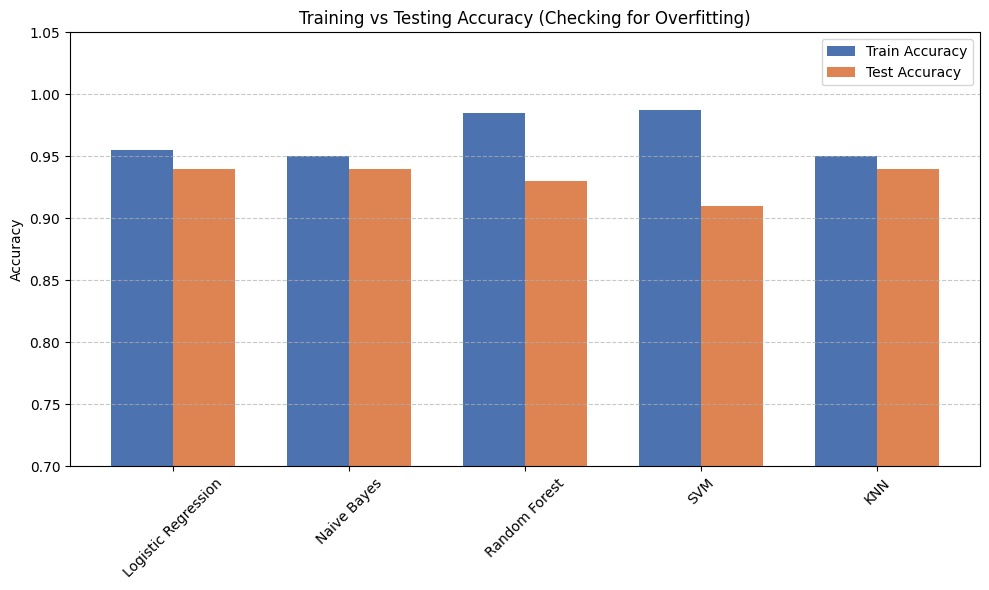

Generating learning curve for Logistic Regression (This might take a minute...)


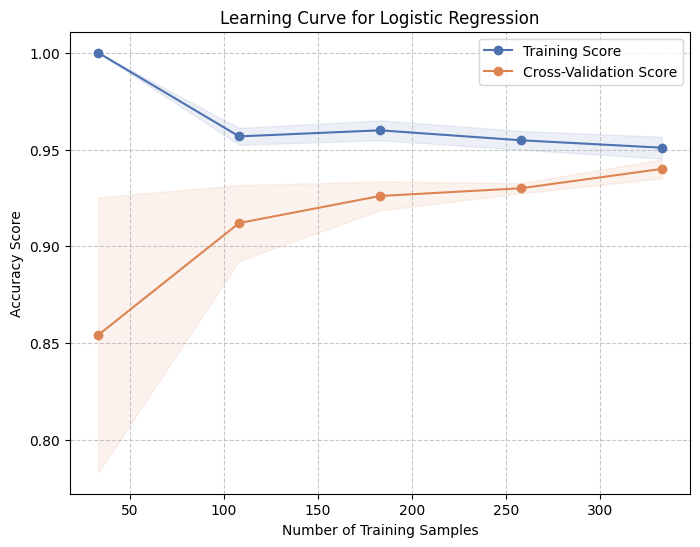

------------------------------------------------------------
Overfitting Analysis:
------------------------------------------------------------
The best model (Logistic Regression) has:
 - Training Accuracy: 0.9550
 - Testing Accuracy:  0.9400
 - Gap (Overfit %):   1.50%

✅  The gap between training and testing accuracy is small and both are high. This indicates good generalization and LOW RISK of overfitting.


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve

# 1. Compare Train vs Test accuracy for all models
train_accuracies = []
test_accuracies = []
model_names_list = []

for name, model in best_models.items():
    model_names_list.append(name)
    train_accuracies.append(accuracy_score(y_train, model.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure(figsize=(10, 6))
x = np.arange(len(model_names_list))
width = 0.35
plt.bar(x - width/2, train_accuracies, width, label='Train Accuracy', color='#4C72B0')
plt.bar(x + width/2, test_accuracies, width, label='Test Accuracy', color='#DD8452')
plt.xticks(x, model_names_list, rotation=45)
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy (Checking for Overfitting)')
plt.legend()
plt.ylim(0.7, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 2. Learning Curve for the Best Model
print(f"Generating learning curve for {best_model_name} (This might take a minute...)")
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X, labels, cv=3, scoring='accuracy', n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', color='#4C72B0', label='Training Score')
plt.plot(train_sizes, test_mean, 'o-', color='#DD8452', label='Cross-Validation Score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='#4C72B0')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='#DD8452')
plt.title(f'Learning Curve for {best_model_name}')
plt.xlabel('Number of Training Samples')
plt.ylabel('Accuracy Score')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Analysis Output
print("-" * 60)
print("Overfitting Analysis:")
print("-" * 60)
best_train_acc = train_accuracies[model_names_list.index(best_model_name)]
best_test_acc = test_accuracies[model_names_list.index(best_model_name)]
print(f"The best model ({best_model_name}) has:")
print(f" - Training Accuracy: {best_train_acc:.4f}")
print(f" - Testing Accuracy:  {best_test_acc:.4f}")
print(f" - Gap (Overfit %):   {(best_train_acc - best_test_acc) * 100:.2f}%")
print("")

if (best_train_acc - best_test_acc) > 0.05:
    print("⚠️  There is a significant gap (>5%) between training and testing accuracy. This indicates potential OVERFITTING. The model is memorizing the training data but struggling to generalize.")
elif (best_train_acc - best_test_acc) < 0:
    print("⚠️  Testing accuracy is higher than training accuracy. This is unusual and might indicate a lucky train/test split or UNDERFITTING.")
elif best_train_acc < 0.80 and best_test_acc < 0.80:
    print("⚠️  Both Training and Testing accuracies are low. This indicates UNDERFITTING. The model is too simple to capture the underlying patterns.")
else:
    print("✅  The gap between training and testing accuracy is small and both are high. This indicates good generalization and LOW RISK of overfitting.")


## 5. Save the Best Model

In [23]:
vectorizer_path = os.path.join(MODEL_DIR, "preprocessor.pkl")
with open(vectorizer_path, "wb") as f:
    pickle.dump(vectorizer, f)

model_path = os.path.join(MODEL_DIR, "models_dict.pkl")
with open(model_path, "wb") as f:
    pickle.dump(best_models, f)

metadata_path = os.path.join(MODEL_DIR, "metadata.pkl")
with open(metadata_path, "wb") as f:
    pickle.dump(all_metadata, f)

print(f"Saved models_dict.pkl to {model_path}")



Saved d:\Projects\MiniProject React\backend\models\trained\preprocessor.pkl
Saved d:\Projects\MiniProject React\backend\models\trained\best_model.pkl
Saved d:\Projects\MiniProject React\backend\models\trained\metadata.pkl

[OK] Best model trained and saved successfully!
